In [1]:
import math
import sys
from pathlib import Path

_here = Path().resolve()
for _p in [_here, *_here.parents]:
    _src = _p / "src"
    if (_src / "qudits_on_qubits" / "__init__.py").is_file():
        repo_root = _p
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break
else:
    raise ImportError(
        "qudits_on_qubits repo root not found; run the notebook from notebooks/ or the repo root"
    )

from qiskit.quantum_info import Statevector, Operator, partial_trace, SparsePauliOp
from qiskit import qpy, QuantumCircuit
import numpy as np
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Session, Batch

from qudits_on_qubits import create_ame_circuit, generate_b_ame
from sympy.functions.combinatorial.numbers import legendre_symbol
from IPython.display import display, Math
from itertools import product
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from igraph import Graph, plot
import matplotlib.pyplot as plt

In [2]:
from qudits_on_qubits.bell_measurements.sampler_circuits import build_sampler_circuits_from_graph, build_sampler_circuits_for_candidate
from iqm.qiskit_iqm.fake_backends.fake_garnet import IQMFakeGarnet
from iqm.iqm_client import CircuitCompilationOptions, DDMode, STANDARD_DD_STRATEGY, DDStrategy
from iqm.qiskit_iqm import IQMProvider
from iqm.qiskit_iqm.iqm_naive_move_pass import transpile_to_IQM
from iqm.iqm_client.transpile import ExistingMoveHandlingOptions

from qudits_on_qubits.bell_measurements.sampler_circuits import run_sampler_circuits_to_counts_by_setting
from qudits_on_qubits.bell_measurements.sampler_circuits import decoding_kwargs_from_metadata
from qudits_on_qubits.bell_measurements.postprocessing import compute_bell_value_from_counts

In [3]:
dd_options = CircuitCompilationOptions(
      dd_mode=DDMode.ENABLED,
      dd_strategy=STANDARD_DD_STRATEGY,
  )

dd_default = CircuitCompilationOptions(
      dd_mode=DDMode.ENABLED)

dd_xy4 = CircuitCompilationOptions(
      dd_mode=DDMode.ENABLED,
      dd_strategy=DDStrategy(
          gate_sequences=[(5, "YXYX", "asap")]
      ),
  )

dd_xy8 = CircuitCompilationOptions(dd_mode=DDMode.ENABLED, 
                                   dd_strategy=DDStrategy(
                                       gate_sequences=[(9, 'XYXYYXYX', 'center')]))

In [4]:
provider_garnet = IQMProvider("https://resonance.iqm.tech/", quantum_computer="garnet", token="REMOVED_SECRET")
backend_garnet = provider_garnet.get_backend(use_metrics=True)

In [5]:
from provider import get_backend, get_backend_error_profile, generate_random_error_profile, to_static_architecture
from iqm.qiskit_iqm.fake_backends.iqm_fake_backend import IQMFakeBackend
from iqm.qiskit_iqm.fake_backends.fake_garnet import IQMFakeGarnet

In [6]:
backend = get_backend(quantum_computer="garnet")
error_profile = generate_random_error_profile(backend=backend)

garnet = IQMFakeGarnet()
garnet_architecture = garnet.architecture

static_garnet_architecture = to_static_architecture(garnet_architecture)

static_garnet_architecture = to_static_architecture(garnet_architecture)

garnet_noisy_backend = IQMFakeBackend(architecture=static_garnet_architecture, error_profile=error_profile)

Backend connected successfully, using garnet

Noise profile: random-noise-profile

T1 / T2 / readout
qubit   T1 [us]   T2 [us]  readout 0->1  readout 1->0  readout avg error  readout asymmetry
  QB1 25.106207 16.597866      0.043671      0.052314           0.047992           0.008643
  QB2 33.782006 30.403806      0.008922      0.017195           0.013058           0.008272
  QB3 24.513432 22.062089      0.044918      0.051891           0.048405           0.006973
  QB4 42.800255 38.520230      0.008030      0.017840           0.012935           0.009810
  QB5 29.897006 26.907306      0.028378      0.037919           0.033148           0.009541
  QB6 47.030806 18.200958      0.010495      0.011542           0.011019           0.001048
  QB7 76.707765 28.597222      0.029634      0.029816           0.029725           0.000182
  QB8 22.340357 20.106321      0.056663      0.051200           0.053932          -0.005463
  QB9 29.460006 26.514005      0.011447      0.010012           0.01072

In [30]:
selected_candidate = "monomial_full__sup012_P012_ph021"
#QuditsOnQubits\artifacts\iqm_runs\selected_best\two_qutrit\stage2_top10_rerun20_20260706\exact\rank01_monomial_full__sup023_P012_ph022
artifact_circuit_dir = repo_root / "artifacts" / "iqm_runs" / "raw" / "quantum_circuits" / "garnet" / "ame43" / selected_candidate
legacy_circuit_dir = repo_root.parent / "QuditsOnQubits" / "basis_direct_encoding_benchmarks" / "quantum_circuits" / "ame43" / selected_candidate

for circuit_dir in (artifact_circuit_dir, legacy_circuit_dir):
    if (circuit_dir / "graph_state_direct_basis.qpy").is_file():
        break
else:
    raise FileNotFoundError(
        "Circuit artifacts not found. Checked:\n"
        f"- {artifact_circuit_dir}\n"
        f"- {legacy_circuit_dir}"
    )

print(f"Loading circuits from: {circuit_dir}")

with (circuit_dir / "graph_state_direct_basis.qpy").open("rb") as f:
    testqc = qpy.load(f)[0]

with (circuit_dir / "graph_state_direct_basis_transpiled.qpy").open("rb") as f:
    qcsuptrans = qpy.load(f)[0]

with (circuit_dir / "F3_W.qpy").open("rb") as f:
    F3sup = qpy.load(f)[0]

Esup = np.load(circuit_dir / "E.npy")

Loading circuits from: C:\Users\szymo\QuditsOnQubits\QuditsOnQubits\artifacts\iqm_runs\raw\quantum_circuits\garnet\ame43\monomial_full__sup012_P012_ph021


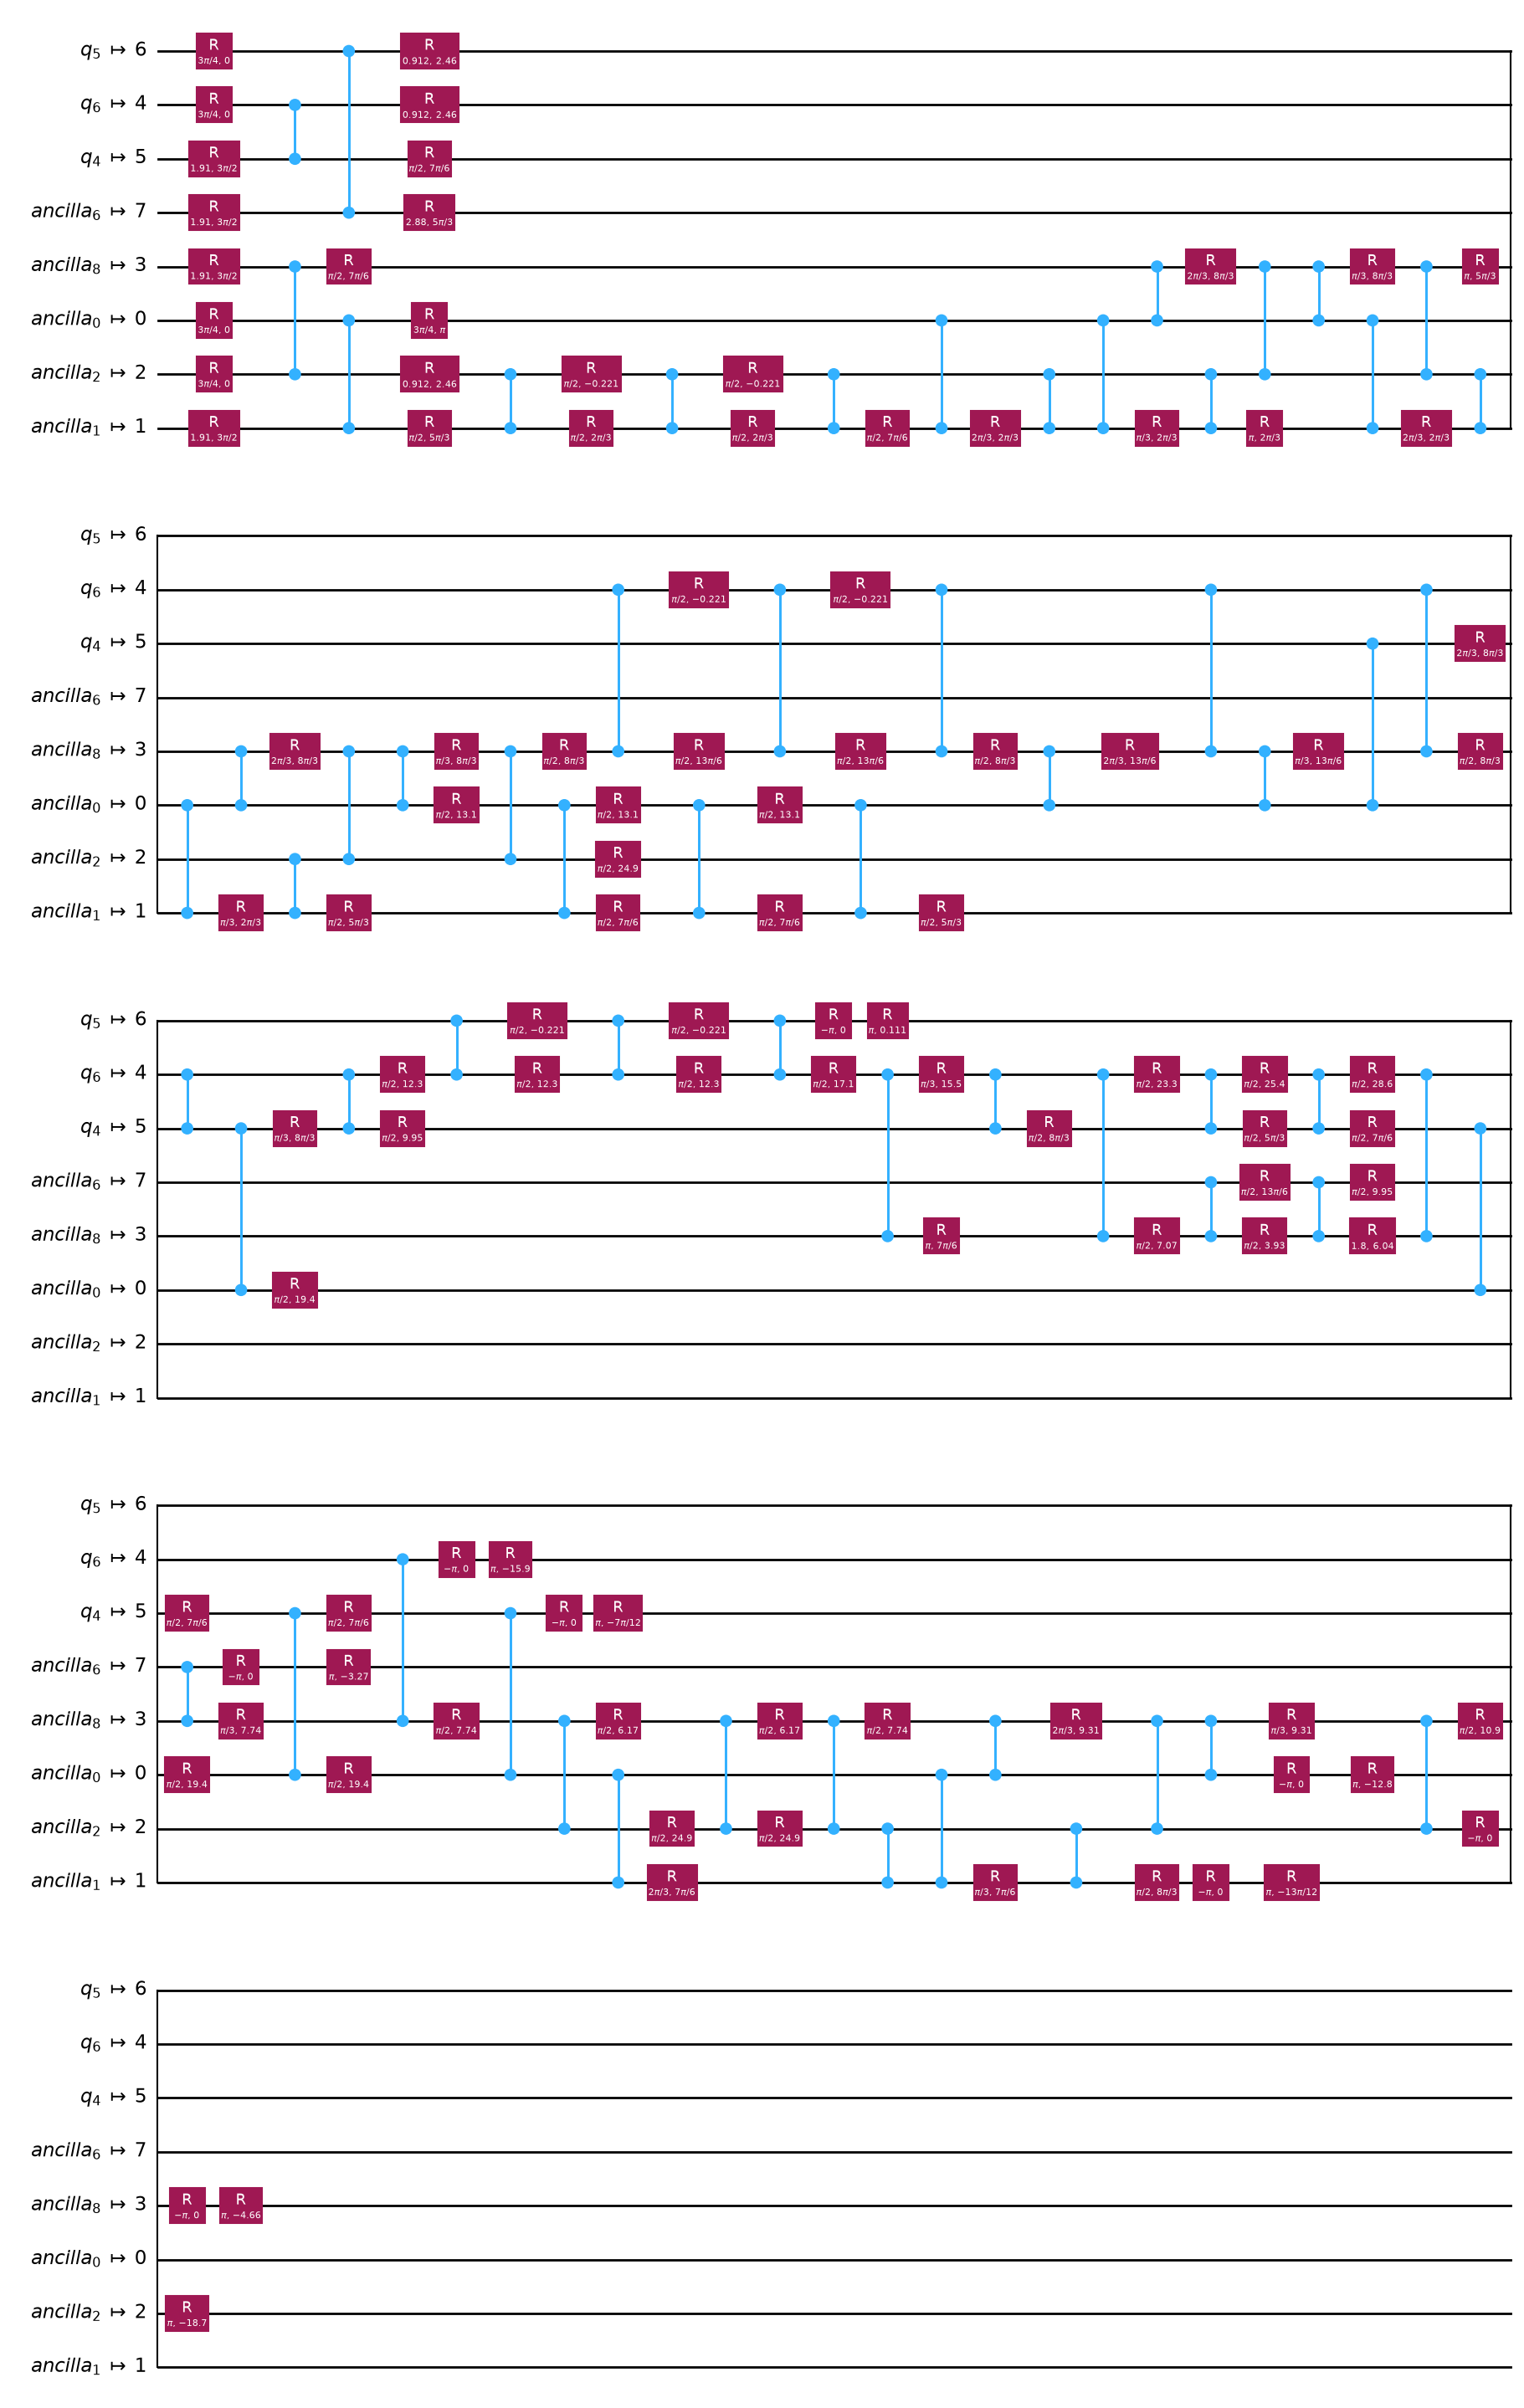

In [31]:
qcsuptrans.draw("mpl")

In [32]:
qcsuptrans.depth()

81

In [33]:
def fold_cz_preserve_layout(qc: QuantumCircuit, n: int = 3) -> QuantumCircuit:
      if n < 1:
          raise ValueError("n musi byc >= 1")
      if n % 2 == 0:
          raise ValueError("Do ZNE uzyj nieparzystego n: 1, 3, 5, ...")

      out = qc.copy()
      old_data = list(out.data)
      out.data.clear()

      for inst in old_data:
          op = inst.operation
          qargs = inst.qubits
          cargs = inst.clbits

          if op.name.lower() == "cz":
              for _ in range(n):
                  out.append(op.copy(), qargs, cargs)
          else:
              out.append(op.copy(), qargs, cargs)

      out.name = f"{qc.name}_czfold{n}"
      return out

In [34]:
layout = qcsuptrans.layout.final_index_layout(filter_ancillas=True)
qutrit_qubits = ((layout[4], layout[5]), (layout[6], layout[7]), (layout[0], layout[1]), (layout[2], layout[3]))

sampler_circuits, metadata = build_sampler_circuits_for_candidate(candidate="ame43", state_circuit=qcsuptrans, E=Esup, qutrit_qubits=qutrit_qubits)
isa_sampler_qc = [transpile_to_IQM(qc, backend=backend_garnet, optimization_level=3, seed_transpiler=2) for qc in sampler_circuits]

In [35]:
isa_sampler_qc[0].depth()

91

In [36]:
isa_sampler_qc_1 = isa_sampler_qc
isa_sampler_qc_3 = [fold_cz_preserve_layout(qc, n=3) for qc in isa_sampler_qc]
isa_sampler_qc_5 = [fold_cz_preserve_layout(qc, n=5) for qc in isa_sampler_qc]

In [37]:
metadata["terms"]

[{'coeff': (0.5685790213016291+0.10025582212028974j),
  'settings': ('A0', 'B0', None, 'D0'),
  'powers': (1, 1, 0, 1),
  'source': 'ame43:0',
  'graph_power': 1},
 {'coeff': (0.568579021301629+0.10025582212028965j),
  'settings': ('A1', 'B0', None, 'D0'),
  'powers': (1, 1, 0, 1),
  'source': 'ame43:1',
  'graph_power': 1},
 {'coeff': (0.5685790213016287+0.10025582212028959j),
  'settings': ('A2', 'B0', None, 'D0'),
  'powers': (1, 1, 0, 1),
  'source': 'ame43:2',
  'graph_power': 1},
 {'coeff': (0.5685790213016291+0.10025582212028962j),
  'settings': ('A0', 'B2', 'C0', 'D0'),
  'powers': (1, 1, 2, 1),
  'source': 'ame43:3',
  'graph_power': 1},
 {'coeff': (-0.3711135994842792+0.4422759654459592j),
  'settings': ('A1', 'B2', 'C0', 'D0'),
  'powers': (1, 1, 2, 1),
  'source': 'ame43:4',
  'graph_power': 1},
 {'coeff': (-0.1974654218173497-0.5425317875662489j),
  'settings': ('A2', 'B2', 'C0', 'D0'),
  'powers': (1, 1, 2, 1),
  'source': 'ame43:5',
  'graph_power': 1},
 {'coeff': (-0.18

In [38]:
counts_by_setting, run_info = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc, metadata, shots=1024*20, transpile_circuits=False, backend=AerSampler())
counts_by_setting3, run_info3 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc_3, metadata, shots=1024*20, transpile_circuits=False, backend=AerSampler())
counts_by_setting5, run_info5 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc_5, metadata, shots=1024*20, transpile_circuits=False, backend=AerSampler())

In [39]:
bell_value = compute_bell_value_from_counts(counts_by_setting, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value3 = compute_bell_value_from_counts(counts_by_setting3, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value5 = compute_bell_value_from_counts(counts_by_setting5, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

bell_value, bell_value3, bell_value5

((8.01549787327716-7.65013052905772e-15j),
 (7.990243444659761-7.615436059538183e-15j),
 (7.997738998703733-7.577272143066693e-15j))

In [40]:
metadata["terms"]

[{'coeff': (0.5685790213016291+0.10025582212028974j),
  'settings': ('A0', 'B0', None, 'D0'),
  'powers': (1, 1, 0, 1),
  'source': 'ame43:0',
  'graph_power': 1},
 {'coeff': (0.568579021301629+0.10025582212028965j),
  'settings': ('A1', 'B0', None, 'D0'),
  'powers': (1, 1, 0, 1),
  'source': 'ame43:1',
  'graph_power': 1},
 {'coeff': (0.5685790213016287+0.10025582212028959j),
  'settings': ('A2', 'B0', None, 'D0'),
  'powers': (1, 1, 0, 1),
  'source': 'ame43:2',
  'graph_power': 1},
 {'coeff': (0.5685790213016291+0.10025582212028962j),
  'settings': ('A0', 'B2', 'C0', 'D0'),
  'powers': (1, 1, 2, 1),
  'source': 'ame43:3',
  'graph_power': 1},
 {'coeff': (-0.3711135994842792+0.4422759654459592j),
  'settings': ('A1', 'B2', 'C0', 'D0'),
  'powers': (1, 1, 2, 1),
  'source': 'ame43:4',
  'graph_power': 1},
 {'coeff': (-0.1974654218173497-0.5425317875662489j),
  'settings': ('A2', 'B2', 'C0', 'D0'),
  'powers': (1, 1, 2, 1),
  'source': 'ame43:5',
  'graph_power': 1},
 {'coeff': (-0.18

AME43 DD XY8

In [41]:
counts_by_setting_garnet_xy8, run_info_garnet_xy8 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc, metadata, shots=1024*20, transpile_circuits=False, backend=backend_garnet, run_options={"circuit_compilation_options": dd_xy8})

In [42]:
bell_value_xy8 = compute_bell_value_from_counts(counts_by_setting_garnet_xy8, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

In [43]:
bell_value_xy8

(4.071227788033578-3.408731630294426e-15j)

In [44]:
counts_by_setting_garnet3_xy8, run_info_garnet3_xy8 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc_3, metadata, shots=1024*20, transpile_circuits=False, backend=backend_garnet, run_options={"circuit_compilation_options": dd_xy8})

In [45]:
bell_value3_xy8 = compute_bell_value_from_counts(counts_by_setting_garnet3_xy8, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

In [46]:
bell_value3_xy8

(1.4273137192678114-8.049116928532385e-16j)

In [47]:
counts_by_setting_garnet5_xy8, run_info_garnet5_xy8 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc_5, metadata, shots=1024*20, transpile_circuits=False, backend=backend_garnet, run_options={"circuit_compilation_options": dd_xy8})

In [48]:
bell_value5_xy8 = compute_bell_value_from_counts(counts_by_setting_garnet5_xy8, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

In [49]:
bell_value5_xy8

(0.31667212390538657+3.400058012914542e-16j)

ZNE with DD XY8 without measurement miti

In [50]:
scale_factors = np.array([1.0, 3.0, 5.0])
bell_values = np.array([bell_value_xy8.real, bell_value3_xy8.real, bell_value5_xy8.real], dtype=float)

coeff = np.polyfit(scale_factors, bell_values, deg=1)
zne_linear = np.polyval(coeff, 0.0)

In [51]:
zne_linear

np.float64(4.754321291831739)

MEAS miti

In [52]:
import mthree

mapping = mthree.utils.final_measurement_mapping(isa_sampler_qc[0])
mapping

{0: 16, 1: 10, 2: 18, 3: 19, 4: 14, 5: 15, 6: 9, 7: 11}

In [53]:
measured_physical_qubits = sorted(set(mapping.values()))
measured_physical_qubits

[9, 10, 11, 14, 15, 16, 18, 19]

In [54]:
from qiskit.circuit import QuantumCircuit
import numpy as np

def build_readout_calibration_matrices(
    backend,
    physical_qubits,
    shots=10_000
):
    """
    Zwraca listę macierzy kalibracyjnych M3.
    Dla kubitów, których nie kalibrujemy, pozostaje None.
    """
    matrices = [None] * backend.num_qubits

    for q in physical_qubits:
        # Przygotowanie |0> i pomiar kubitu q
        cal_0 = QuantumCircuit(backend.num_qubits, 1)
        cal_0.measure(q, 0)

        # Przygotowanie |1> i pomiar kubitu q
        cal_1 = QuantumCircuit(backend.num_qubits, 1)
        cal_1.x(q)
        cal_1.measure(q, 0)

        counts_0, counts_1 = backend.run(
            [cal_0, cal_1],
            shots=shots
        ).result().get_counts()

        # P(odczytano 1 | przygotowano 0)
        p10 = counts_0.get("1", 0) / shots

        # P(odczytano 0 | przygotowano 1)
        p01 = counts_1.get("0", 0) / shots

        # Kolumny: stan przygotowany |0>, |1>
        # Wiersze: stan odczytany  |0>, |1>
        matrices[q] = np.array(
            [
                [1 - p10, p01],
                [p10, 1 - p01]
            ],
            dtype=np.float32
        )

        print(f"Qubit {q}:")
        print(matrices[q])

    return matrices

In [55]:
calibration_matrix = build_readout_calibration_matrices(backend_garnet, measured_physical_qubits, shots=10000)

Qubit 9:
[[0.9896 0.0159]
 [0.0104 0.9841]]
Qubit 10:
[[0.9944 0.0107]
 [0.0056 0.9893]]
Qubit 11:
[[0.9674 0.0208]
 [0.0326 0.9792]]
Qubit 14:
[[0.9781 0.0088]
 [0.0219 0.9912]]
Qubit 15:
[[0.9716 0.0219]
 [0.0284 0.9781]]
Qubit 16:
[[0.9888 0.0113]
 [0.0112 0.9887]]
Qubit 18:
[[0.9638 0.0156]
 [0.0362 0.9844]]
Qubit 19:
[[0.9809 0.0144]
 [0.0191 0.9856]]


In [56]:
mit = mthree.M3Mitigation()

mit.cals_from_matrices(calibration_matrix)

def apply_mitigation(counts_by_setting, mit, mapping):
    quasi = []

    for res in list(counts_by_setting.values()):
        quasi.append(mit.apply_correction(res, mapping, return_mitigation_overhead=True))

    quasi_miti = {}

    for i, setting in zip(quasi, list(counts_by_setting.keys())):
        quasi_temp = {}
        for key in i.keys():
            quasi_temp[key] = int(i[key]*1024*20)
        quasi_miti[setting] = quasi_temp

    return quasi_miti

In [57]:
counts_by_setting_garnet_miti = apply_mitigation(counts_by_setting_garnet_xy8, mit, mapping)
counts_by_setting_garnet_miti3 = apply_mitigation(counts_by_setting_garnet3_xy8, mit, mapping)
counts_by_setting_garnet_miti5 = apply_mitigation(counts_by_setting_garnet5_xy8, mit, mapping)

In [ ]:
for i in list(counts_by_setting_garnet_miti.keys()):
    for j in list(counts_by_setting_garnet_miti[i].keys()):
        if counts_by_setting_garnet_miti[i][j] < 0:
            counts_by_setting_garnet_miti[i][j] = 0

In [79]:
bell_value_miti = compute_bell_value_from_counts(counts_by_setting_garnet_miti, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value_miti3 = compute_bell_value_from_counts(counts_by_setting_garnet_miti3, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value_miti5 = compute_bell_value_from_counts(counts_by_setting_garnet_miti5, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

In [80]:
scale_factors = np.array([1.0, 3.0, 5.0])
bell_values = np.array([bell_value_miti.real, bell_value_miti3.real, bell_value_miti5.real], dtype=float)

coeff = np.polyfit(scale_factors, bell_values, deg=1)
zne_linear = np.polyval(coeff, 0.0)

In [81]:
zne_linear

np.float64(5.482750681924072)